
========== WEEKLY ALARM TREND ==========



,Week Start,PaymentGateway,Tigo,Grand Total
0,7/6/2026,1625,468,2093
1,7/13/2026,1383,354,1737
2,7/20/2026,1645,533,2178
3,7/27/2026,1519,789,2308
4,8/3/2026,1655,663,2318


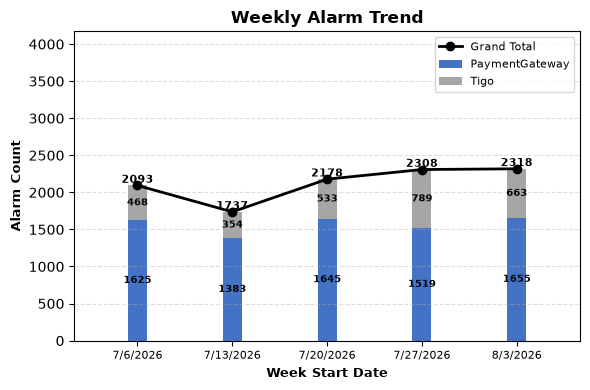

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read Excel file
file_path = "./required_files/biweekly_alarms.xlsx"

df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(subset=["Date"])

# Get week start date (Monday)
df["Week_Start"] = (
    df["Date"]
    - pd.to_timedelta(
        df["Date"].dt.weekday,
        unit="D"
    )
)

# Classify alarms
def classify_alarm(alarm):

    alarm = str(alarm).strip().lower()

    if alarm.startswith("paymentgateway"): #if alarm.startswith("paymentgateway-prod"):
        return "PaymentGateway"

    if alarm.startswith("tigo"): #if alarm.startswith("tigo-cognito-prod"):
        return "Tigo"

    return "Other"

# Add application classification
df["Application"] = df["AlarmDescription"].apply(
    classify_alarm
)

# Keep only PaymentGateway and Tigo alarms
df = df[
    df["Application"].isin(
        ["PaymentGateway", "Tigo"]
    )
]

# Weekly counts
weekly_counts = (
    df.groupby(
        ["Week_Start", "Application"]
    )
    .size()
    .unstack(fill_value=0)
)

# Ensure both columns exist
for col in ["PaymentGateway", "Tigo"]:

    if col not in weekly_counts.columns:
        weekly_counts[col] = 0

weekly_counts = weekly_counts.sort_index()

# X-axis labels
weeks = [
    f"{d.month}/{d.day}/{d.year}"
    for d in weekly_counts.index
]

# Data
paymentgateway = weekly_counts["PaymentGateway"]
tigo = weekly_counts["Tigo"]

grand_total = paymentgateway + tigo

# Display Weekly Summary
weekly_summary = pd.DataFrame({
    "Week Start": weeks,
    "PaymentGateway": paymentgateway.values,
    "Tigo": tigo.values,
    "Grand Total": grand_total.values
})

print("\n========== WEEKLY ALARM TREND ==========\n")
display(weekly_summary)

# Very compact spacing between bars
x = np.arange(len(weeks)) * 0.03

# Small chart size
plt.figure(figsize=(6, 4))

# PaymentGateway bars
bars_pg = plt.bar(
    x,
    paymentgateway,
    width=0.006,
    color="#4472C4",
    label="PaymentGateway"
)

# Tigo bars
bars_tigo = plt.bar(
    x,
    tigo,
    width=0.006,
    bottom=paymentgateway,
    color="#A6A6A6",
    label="Tigo"
)

# Grand Total line
plt.plot(
    x,
    grand_total,
    color="black",
    marker="o",
    linewidth=2,
    label="Grand Total"
)

# PaymentGateway labels inside bars
for bar in bars_pg:

    height = bar.get_height()

    if height > 0:

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            str(int(height)),
            ha="center",
            va="center",
            color="black",
            fontsize=7,
            fontweight="bold"
        )

# Tigo labels inside bars
for idx, bar in enumerate(bars_tigo):

    height = bar.get_height()

    if height > 0:

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            paymentgateway.iloc[idx] + height / 2,
            str(int(height)),
            ha="center",
            va="center",
            color="black",
            fontsize=7,
            fontweight="bold"
        )

# Grand Total labels above line
for idx, total in enumerate(grand_total):

    plt.text(
        x[idx],
        total + 0.3,
        str(int(total)),
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold",
        color="black"
    )

# X-axis labels
plt.xticks(
    x,
    weeks,
    fontsize=8
)

# Remove unnecessary margins
plt.margins(x=0.001)

plt.xlim(
    min(x) - 0.02,
    max(x) + 0.02
)

# Add extra headroom for legend (inside chart, no overlap)
max_value = grand_total.max()

plt.ylim(
    0,
    max(
        4000,
        max_value * 1.8
    )
)
# Chart title
plt.title(
    "Weekly Alarm Trend",
    fontsize=12,
    fontweight="bold"
)

# Axis labels
plt.xlabel(
    "Week Start Date",
    fontsize=9,
    fontweight="bold"
)

plt.ylabel(
    "Alarm Count",
    fontsize=9,
    fontweight="bold"
)

# Legend inside top-right
plt.legend(
    loc="upper right",
    fontsize=8,
    frameon=True
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [5]:
import pandas as pd

# Read Excel
file_path = "./required_files/biweekly_alarms.xlsx"

df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(subset=["Date"])

# Create week labels
df["Week"] = (
    df["Date"]
    - pd.to_timedelta(
        df["Date"].dt.weekday,
        unit="D"
    )
).dt.strftime("%d-%B")

# Weekly alarm count matrix
alarm_weekly = pd.crosstab(
    df["AlarmDescription"],
    df["Week"]
)

# Sort week columns chronologically
week_order = (
    df.groupby("Week")["Date"]
    .min()
    .sort_values()
    .index
)

alarm_weekly = alarm_weekly[
    list(week_order)
]


# Read Top Ageing Tickets file
ageing_file = "./required_files/topageing_tickets.xlsx"

ageing_df = pd.read_excel(ageing_file)

# Clean column names
ageing_df.columns = ageing_df.columns.str.strip()

# Clean Short Description
ageing_df["Short description"] = (
    ageing_df["Short description"]
    .astype(str)
    .str.strip()
)

# Build Alarm -> Ref mapping
ticket_map = {}

for alarm in df["AlarmDescription"].dropna().unique():

    matching_refs = ageing_df.loc[
        ageing_df["Short description"]
        .str.contains(
            str(alarm),
            case=False,
            na=False,
            regex=False
        ),
        "Ref"
    ]

    ticket_map[alarm] = ", ".join(
        sorted(
            {
                str(ref).strip()
                for ref in matching_refs
                if pd.notna(ref)
                and str(ref).strip()
            }
        )
    )

# Total count column
alarm_weekly["Total"] = alarm_weekly.sum(
    axis=1
)

# Actual number of days
total_days = df["Date"].nunique()


def prepare_report(report_df):

    report_df = report_df.copy()

    report_df["Avg. Per Day"] = (
        report_df["Total"]
        / total_days
    ).round().astype(int)

    report_df["Ticket Number"] = (
        report_df.index.map(ticket_map)
    )

    report_df.columns.name = None

    report_df.reset_index(
        inplace=True
    )

    report_df.rename(
        columns={
            "AlarmDescription": "Alarm Name"
        },
        inplace=True
    )

    report_df.insert(
        0,
        "S.NO",
        range(
            1,
            len(report_df) + 1
        )
    )

    report_df = report_df[
        ["S.NO", "Alarm Name"]
        + list(week_order)
        + [
            "Total",
            "Avg. Per Day",
            "Ticket Number"
        ]
    ]

    return report_df


def get_highest_lowest(source_df):

    highest = (
        source_df
        .sort_values(
            by="Total",
            ascending=False
        )
        .head(5)
    )

    lowest = (
        source_df[
            source_df["Total"] > 0
        ]
        .sort_values(
            by="Total",
            ascending=True
        )
        .head(5)
    )

    return (
        prepare_report(highest),
        prepare_report(lowest)
    )


# ------------------------
# PaymentGateway
# ------------------------

pg_alarms = alarm_weekly[
    alarm_weekly.index.str.startswith(
        "PaymentGateway",
        na=False
    )
]

pg_highest, pg_lowest = (
    get_highest_lowest(pg_alarms)
)

pg_output_file = (
    "./alarm_report/reports/"
    "Top10_PaymentGateway_Alarms.xlsx"
)

with pd.ExcelWriter(
    pg_output_file,
    engine="openpyxl"
) as writer:

    pd.DataFrame(
        [["TOP 5 HIGHEST TRIGGERED ALARMS"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=0,
        index=False,
        header=False
    )

    pg_highest.to_excel(
        writer,
        sheet_name="Report",
        startrow=2,
        index=False
    )

    pd.DataFrame(
        [["TOP 5 LOWEST TRIGGERED ALARMS"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=len(pg_highest) + 5,
        index=False,
        header=False
    )

    pg_lowest.to_excel(
        writer,
        sheet_name="Report",
        startrow=len(pg_highest) + 7,
        index=False
    )

# ------------------------
# Tigo
# ------------------------

tigo_alarms = alarm_weekly[
    alarm_weekly.index.str.startswith(
        "tigo",
        na=False
    )
]

tigo_highest, tigo_lowest = (
    get_highest_lowest(tigo_alarms)
)

tigo_output_file = (
    "./alarm_report/reports/"
    "Top10_Tigo_Alarms.xlsx"
)

with pd.ExcelWriter(
    tigo_output_file,
    engine="openpyxl"
) as writer:

    pd.DataFrame(
        [["TOP 5 HIGHEST TRIGGERED ALARMS"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=0,
        index=False,
        header=False
    )

    tigo_highest.to_excel(
        writer,
        sheet_name="Report",
        startrow=2,
        index=False
    )

    pd.DataFrame(
        [["TOP 5 LOWEST TRIGGERED ALARMS"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=len(tigo_highest) + 5,
        index=False,
        header=False
    )

    tigo_lowest.to_excel(
        writer,
        sheet_name="Report",
        startrow=len(tigo_highest) + 7,
        index=False
    )

# ------------------------
# Display in Notebook
# ------------------------

print("\n========== PAYMENTGATEWAY ==========\n")

print("TOP 5 HIGHEST TRIGGERED ALARMS")
display(pg_highest)

print("TOP 5 LOWEST TRIGGERED ALARMS")
display(pg_lowest)

print("\n========== TIGO ==========\n")

print("TOP 5 HIGHEST TRIGGERED ALARMS")
display(tigo_highest)

print("TOP 5 LOWEST TRIGGERED ALARMS")
display(tigo_lowest)

print(
    f"\nPaymentGateway report saved:\n"
    f"{pg_output_file}"
)

print(
    f"\nTigo report saved:\n"
    f"{tigo_output_file}"
)

print(
    f"\nTotal unique dates considered for Avg. Per Day: "
    f"{total_days}"
)


========== PAYMENTGATEWAY ==========

TOP 5 HIGHEST TRIGGERED ALARMS


,S.NO,Alarm Name,06-July,13-July,20-July,27-July,03-August,Total,Avg. Per Day,Ticket Number
0,1,PaymentGateway-prod-API-5XXErrors,496,390,665,465,627,2643,76,"DIGSUPPORT-10998, DIGSUPPORT-12401, DIGSUPPORT..."
1,2,PaymentGateway-prod-Enrollment-Microservice-Ex...,228,224,263,214,228,1157,33,"DIGSUPPORT-12626, DIGSUPPORT-13235, DIGSUPPORT..."
2,3,PaymentGateway-prod-Event-Message-Processor-Ex...,155,152,142,147,158,754,22,"DIGSUPPORT-16015, DIGSUPPORT-16579, DIGSUPPORT..."
3,4,PaymentGateway-prod-FulfillmentCallback-Worker...,86,69,76,80,72,383,11,
4,5,PaymentGateway-prod-PaymentCallback-Worker-Exc...,80,75,64,83,71,373,11,


TOP 5 LOWEST TRIGGERED ALARMS


,S.NO,Alarm Name,06-July,13-July,20-July,27-July,03-August,Total,Avg. Per Day,Ticket Number
0,1,PaymentGateway-prod-CaptureCallback-Worker-Exc...,0,0,0,1,0,1,0,
1,2,PaymentGateway-prod-Refund-Worker-Exceptions,0,0,0,0,1,1,0,DIGSUPPORT-12274
2,3,PaymentGateway-prod-capture-queue-ApproximateA...,0,0,1,0,0,1,0,
3,4,PaymentGateway-prod-authreversal-queue-Approxi...,0,1,0,0,0,1,0,
4,5,PaymentGateway-prod-RP-Enrollment-Processor-Ex...,0,0,1,0,0,1,0,



========== TIGO ==========

TOP 5 HIGHEST TRIGGERED ALARMS


,S.NO,Alarm Name,06-July,13-July,20-July,27-July,03-August,Total,Avg. Per Day,Ticket Number
0,1,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,81,27,233,352,360,1053,30,"DIGSUPPORT-10686, DIGSUPPORT-15183, I-014171, ..."
1,2,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,102,115,133,318,223,891,25,"I-017386, I-034913, I-069597, I-074517, I-0757..."
2,3,tigo-cognito-prod-master-Monitoring-EventsQueu...,107,92,78,55,20,352,10,
3,4,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,57,40,19,14,13,143,4,"I-033685, I-076490"
4,5,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,37,33,19,27,18,134,4,"I-035125, I-069631, I-076635"


TOP 5 LOWEST TRIGGERED ALARMS


,S.NO,Alarm Name,06-July,13-July,20-July,27-July,03-August,Total,Avg. Per Day,Ticket Number
0,1,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,0,0,1,0,0,1,0,
1,2,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,0,0,1,0,0,1,0,
2,3,tigo-cognito-prod-master-MonitoringOTP-UI11ZHW...,0,0,1,0,0,1,0,
3,4,tigo-cognito-prod-master-MonitoringOTP-UI11ZHW...,2,0,0,0,0,2,0,
4,5,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,0,0,0,0,3,3,0,



PaymentGateway report saved:
./alarm_report/reports/Top10_PaymentGateway_Alarms.xlsx

Tigo report saved:
./alarm_report/reports/Top10_Tigo_Alarms.xlsx

Total unique dates considered for Avg. Per Day: 35


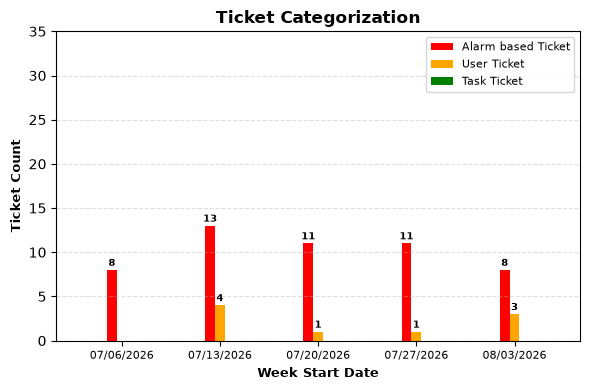

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read Excel file
file_path = "./required_files/biweekly_tracker.xlsx"

df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Convert Ticket Assigned Date/Time to datetime
df["Ticket Assigned Date/Time"] = pd.to_datetime(
    df["Ticket Assigned Date/Time"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(
    subset=["Ticket Assigned Date/Time"]
)

# Clean Ticket Categorization values
df["Ticket Categorization"] = (
    df["Ticket Categorization"]
    .astype(str)
    .str.replace("\n", "", regex=False)
    .str.strip()
)

# Calculate Week Start Date (Monday)
df["Week_Start"] = (
    df["Ticket Assigned Date/Time"]
    - pd.to_timedelta(
        df["Ticket Assigned Date/Time"].dt.weekday,
        unit="D"
    )
).dt.normalize()

# Weekly Counts
weekly_counts = (
    df.groupby(
        ["Week_Start", "Ticket Categorization"]
    )
    .size()
    .unstack(fill_value=0)
)

# Sort Weeks
weekly_counts = weekly_counts.sort_index()

# Ensure required categories exist
for category in [
    "Alarm based Ticket",
    "User Ticket",
    "Task Ticket"
]:
    if category not in weekly_counts.columns:
        weekly_counts[category] = 0

# Week Labels
weeks = [
    week.strftime("%m/%d/%Y")
    for week in weekly_counts.index
]

# Data (Required Order)
alarm_ticket = weekly_counts["Alarm based Ticket"]
user_ticket = weekly_counts["User Ticket"]
task_ticket = weekly_counts["Task Ticket"]

# Compact spacing between week groups
x = np.arange(len(weeks)) * 0.12

# Thin bars
bar_width = 0.012

# Figure
plt.figure(figsize=(6, 4))

# Alarm Ticket - Red
bars_alarm = plt.bar(
    x - 0.012,
    alarm_ticket,
    width=bar_width,
    color="red",
    label="Alarm based Ticket"
)

# User Ticket - Orange
bars_user = plt.bar(
    x,
    user_ticket,
    width=bar_width,
    color="orange",
    label="User Ticket"
)

# Task Ticket - Green
bars_task = plt.bar(
    x + 0.012,
    task_ticket,
    width=bar_width,
    color="green",
    label="Task Ticket"
)

# Count Labels Above Bars
for bars in [bars_alarm, bars_user, bars_task]:

    for bar in bars:

        height = bar.get_height()

        if height > 0:

            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.2,
                str(int(height)),
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold",
                color="black"
            )

# Dynamic Y-axis with minimum 35
max_value = max(
    alarm_ticket.max(),
    user_ticket.max(),
    task_ticket.max()
)

y_max = max(
    35,
    ((int(max_value) // 5) + 1) * 5
)

plt.ylim(0, y_max)

plt.yticks(
    range(
        0,
        y_max + 1,
        5
    )
)

# X-axis Labels
plt.xticks(
    x,
    weeks,
    fontsize=8
)

# Center the week groups in the chart
padding = 0.08

plt.xlim(
    min(x) - padding,
    max(x) + padding
)

# Title
plt.title(
    "Ticket Categorization",
    fontsize=12,
    fontweight="bold"
)

# Axis Labels
plt.xlabel(
    "Week Start Date",
    fontsize=9,
    fontweight="bold"
)

plt.ylabel(
    "Ticket Count",
    fontsize=9,
    fontweight="bold"
)

# Legend Order:
# Alarm based Ticket -> User Ticket -> Task Ticket
plt.legend(
    [bars_alarm, bars_user, bars_task],
    [
        "Alarm based Ticket",
        "User Ticket",
        "Task Ticket"
    ],
    loc="upper right",
    fontsize=8,
    frameon=True
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

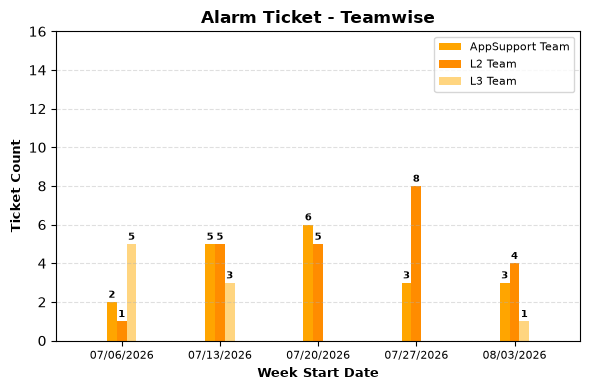

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read Excel file
file_path = "./required_files/biweekly_tracker.xlsx"

df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Convert date column
df["Ticket Assigned Date/Time"] = pd.to_datetime(
    df["Ticket Assigned Date/Time"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(
    subset=["Ticket Assigned Date/Time"]
)

# Clean values
df["Ticket Categorization"] = (
    df["Ticket Categorization"]
    .astype(str)
    .str.replace("\n", "", regex=False)
    .str.strip()
)

df["Ticket Assigned To"] = (
    df["Ticket Assigned To"]
    .astype(str)
    .str.strip()
)

# Keep only Alarm based Ticket
df = df[
    df["Ticket Categorization"]
    .str.lower()
    .eq("alarm based ticket")
]

# Calculate Week Start Date (Monday)
df["Week_Start"] = (
    df["Ticket Assigned Date/Time"]
    - pd.to_timedelta(
        df["Ticket Assigned Date/Time"].dt.weekday,
        unit="D"
    )
).dt.normalize()

# Team Classification
def classify_team(team):

    team = str(team).lower()

    if "appsupport" in team:
        return "AppSupport Team"

    elif "l2" in team:
        return "L2 Team"

    elif "l3" in team:
        return "L3 Team"

    return "Other"


df["Team"] = df["Ticket Assigned To"].apply(
    classify_team
)

# Weekly Counts
weekly_counts = (
    df.groupby(
        ["Week_Start", "Team"]
    )
    .size()
    .unstack(fill_value=0)
)

weekly_counts = weekly_counts.sort_index()

# Ensure required columns exist
for category in [
    "AppSupport Team",
    "L2 Team",
    "L3 Team"
]:
    if category not in weekly_counts.columns:
        weekly_counts[category] = 0

# Week Labels
weeks = [
    week.strftime("%m/%d/%Y")
    for week in weekly_counts.index
]

# Data
appsupport = weekly_counts["AppSupport Team"]
l2_team = weekly_counts["L2 Team"]
l3_team = weekly_counts["L3 Team"]

# Compact spacing between week groups
x = np.arange(len(weeks)) * 0.12

# Thin bars
bar_width = 0.012

# Figure
plt.figure(figsize=(6, 4))

# AppSupport Team
bars_app = plt.bar(
    x - 0.012,
    appsupport,
    width=bar_width,
    color="orange",
    label="AppSupport Team"
)

# L2 Team
bars_l2 = plt.bar(
    x,
    l2_team,
    width=bar_width,
    color="darkorange",
    label="L2 Team"
)

# L3 Team
bars_l3 = plt.bar(
    x + 0.012,
    l3_team,
    width=bar_width,
    color="#FFD580",
    label="L3 Team"
)

# Count Labels Above Bars
for bars in [bars_app, bars_l2, bars_l3]:

    for bar in bars:

        height = bar.get_height()

        if height > 0:

            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.1,
                str(int(height)),
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold"
            )

# Dynamic Y-axis with minimum 16
max_value = max(
    appsupport.max(),
    l2_team.max(),
    l3_team.max()
)

y_max = max(
    16,
    ((int(max_value) // 2) + 1) * 2
)

plt.ylim(0, y_max)

plt.yticks(
    range(
        0,
        y_max + 1,
        2
    )
)

# X-axis Labels
plt.xticks(
    x,
    weeks,
    fontsize=8
)

# Center graph
padding = 0.08

plt.xlim(
    min(x) - padding,
    max(x) + padding
)

# Title
plt.title(
    "Alarm Ticket - Teamwise",
    fontsize=12,
    fontweight="bold"
)

# Axis Labels
plt.xlabel(
    "Week Start Date",
    fontsize=9,
    fontweight="bold"
)

plt.ylabel(
    "Ticket Count",
    fontsize=9,
    fontweight="bold"
)

# Legend
plt.legend(
    loc="upper right",
    fontsize=8,
    frameon=True
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

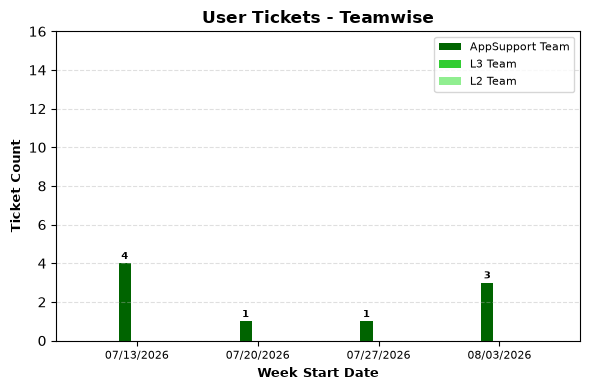

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read Excel file
file_path = "./required_files/biweekly_tracker.xlsx"

df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Convert date column
df["Ticket Assigned Date/Time"] = pd.to_datetime(
    df["Ticket Assigned Date/Time"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(
    subset=["Ticket Assigned Date/Time"]
)

# Clean values
df["Ticket Categorization"] = (
    df["Ticket Categorization"]
    .astype(str)
    .str.replace("\n", "", regex=False)
    .str.strip()
)

df["Ticket Assigned To"] = (
    df["Ticket Assigned To"]
    .astype(str)
    .str.strip()
)

# Keep only User Tickets
df = df[
    df["Ticket Categorization"]
    .str.lower()
    .eq("user ticket")
]

# Calculate Week Start Date (Monday)
df["Week_Start"] = (
    df["Ticket Assigned Date/Time"]
    - pd.to_timedelta(
        df["Ticket Assigned Date/Time"].dt.weekday,
        unit="D"
    )
).dt.normalize()

# Team Classification
def classify_team(team):

    team = str(team).lower()

    if "appsupport" in team:
        return "AppSupport Team"

    elif "l2" in team:
        return "L2 Team"

    elif "l3" in team:
        return "L3 Team"

    return "Other"


df["Team"] = df["Ticket Assigned To"].apply(
    classify_team
)

# Weekly Counts
weekly_counts = (
    df.groupby(
        ["Week_Start", "Team"]
    )
    .size()
    .unstack(fill_value=0)
)

weekly_counts = weekly_counts.sort_index()

# Ensure required columns exist
for category in [
    "AppSupport Team",
    "L3 Team",
    "L2 Team"
]:
    if category not in weekly_counts.columns:
        weekly_counts[category] = 0

# Week Labels
weeks = [
    week.strftime("%m/%d/%Y")
    for week in weekly_counts.index
]

# Data
appsupport = weekly_counts["AppSupport Team"]
l3_team = weekly_counts["L3 Team"]
l2_team = weekly_counts["L2 Team"]

# Compact spacing between week groups
x = np.arange(len(weeks)) * 0.12

# Thin bars
bar_width = 0.012

# Figure
plt.figure(figsize=(6, 4))

# AppSupport Team - Dark Green
bars_app = plt.bar(
    x - 0.012,
    appsupport,
    width=bar_width,
    color="#006400",
    label="AppSupport Team"
)

# L3 Team - Medium Green
bars_l3 = plt.bar(
    x,
    l3_team,
    width=bar_width,
    color="#32CD32",
    label="L3 Team"
)

# L2 Team - Light Green
bars_l2 = plt.bar(
    x + 0.012,
    l2_team,
    width=bar_width,
    color="#90EE90",
    label="L2 Team"
)

# Count Labels Above Bars
for bars in [bars_app, bars_l3, bars_l2]:

    for bar in bars:

        height = bar.get_height()

        if height > 0:

            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.1,
                str(int(height)),
                ha="center",
                va="bottom",
                fontsize=7,
                fontweight="bold"
            )

# Dynamic Y-axis with minimum 16
max_value = max(
    appsupport.max(),
    l3_team.max(),
    l2_team.max()
)

y_max = max(
    16,
    ((int(max_value) // 2) + 1) * 2
)

plt.ylim(0, y_max)

plt.yticks(
    range(
        0,
        y_max + 1,
        2
    )
)

# X-axis Labels
plt.xticks(
    x,
    weeks,
    fontsize=8
)

# Center Graph
padding = 0.08

plt.xlim(
    min(x) - padding,
    max(x) + padding
)

# Title
plt.title(
    "User Tickets - Teamwise",
    fontsize=12,
    fontweight="bold"
)

# Axis Labels
plt.xlabel(
    "Week Start Date",
    fontsize=9,
    fontweight="bold"
)

plt.ylabel(
    "Ticket Count",
    fontsize=9,
    fontweight="bold"
)

# Legend Order
plt.legend(
    [bars_app, bars_l3, bars_l2],
    [
        "AppSupport Team",
        "L3 Team",
        "L2 Team"
    ],
    loc="upper right",
    fontsize=8,
    frameon=True
)

# Grid
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [11]:
# Difference = Current Week - Previous Week
# Difference > 0 → Increased
# Difference < 0 → Decreased
# Previous Week = 0 and Current Week > 0 → Newly Triggered
# Difference = 0 → No Change (ignored)

import pandas as pd

# Read Excel file
file_path = "./required_files/biweekly_alarms.xlsx"

df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(
    subset=["Date"]
)

# Calculate Week Start Date (Monday)
df["Week_Start"] = (
    df["Date"]
    - pd.to_timedelta(
        df["Date"].dt.weekday,
        unit="D"
    )
).dt.normalize()


# --------------------------------------------------
# Function to Generate Alarm Comparison Report
# --------------------------------------------------

def generate_alarm_comparison(alarm_df):

    # Weekly Alarm Count Matrix
    alarm_weekly = pd.crosstab(
        alarm_df["AlarmDescription"],
        alarm_df["Week_Start"]
    )

    alarm_weekly = alarm_weekly.reindex(
        sorted(alarm_weekly.columns),
        axis=1
    )

    if len(alarm_weekly.columns) < 2:

        raise Exception(
            "At least 2 weeks of data are required for comparison."
        )

    previous_week = alarm_weekly.columns[-2]
    current_week = alarm_weekly.columns[-1]

    # Build Comparison DataFrame
    comparison_df = pd.DataFrame({
        "Alarm Name": alarm_weekly.index,
        f"Previous Week ({previous_week.date()})":
            alarm_weekly[previous_week].values,
        f"Current Week ({current_week.date()})":
            alarm_weekly[current_week].values
    })

    # Difference
    comparison_df["Difference"] = (
        comparison_df[
            f"Current Week ({current_week.date()})"
        ]
        -
        comparison_df[
            f"Previous Week ({previous_week.date()})"
        ]
    )

    # Percentage
    def calculate_percentage(row):

        previous = row[
            f"Previous Week ({previous_week.date()})"
        ]

        difference = row["Difference"]

        if previous == 0:
            return "N/A"

        percentage = (
            difference / previous
        ) * 100

        return f"{round(percentage, 2)}%"

    comparison_df["Percentage"] = (
        comparison_df.apply(
            calculate_percentage,
            axis=1
        )
    )

    comparison_df = comparison_df[
        [
            "Alarm Name",
            f"Previous Week ({previous_week.date()})",
            f"Current Week ({current_week.date()})",
            "Difference",
            "Percentage"
        ]
    ]

    # Top Increased Alarms
    top_increased = (
        comparison_df[
            comparison_df["Difference"] > 0
        ]
        .sort_values(
            by="Difference",
            ascending=False
        )
        #.head(10)
        .reset_index(drop=True)
    )

    # Top Decreased Alarms
    top_decreased = (
        comparison_df[
            comparison_df["Difference"] < 0
        ]
        .sort_values(
            by="Difference",
            ascending=True
        )
        #.head(10)
        .reset_index(drop=True)
    )

    # Newly Triggered Alarms
    new_alarms = (
        comparison_df[
            (
                comparison_df[
                    f"Previous Week ({previous_week.date()})"
                ] == 0
            )
            &
            (
                comparison_df[
                    f"Current Week ({current_week.date()})"
                ] > 0
            )
        ]
        .sort_values(
            by="Difference",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return (
        previous_week,
        current_week,
        top_increased,
        top_decreased,
        new_alarms
    )


# --------------------------------------------------
# PAYMENTGATEWAY ALARMS
# --------------------------------------------------

paymentgateway_df = df[
    df["AlarmDescription"]
    .str.startswith(
        "PaymentGateway",
        na=False
    )
]

(
    pg_previous_week,
    pg_current_week,
    pg_top_increased,
    pg_top_decreased,
    pg_new_alarms
) = generate_alarm_comparison(
    paymentgateway_df
)


# --------------------------------------------------
# TIGO ALARMS
# --------------------------------------------------

tigo_df = df[
    df["AlarmDescription"]
    .str.startswith(
        "tigo",
        na=False
    )
]

(
    tigo_previous_week,
    tigo_current_week,
    tigo_top_increased,
    tigo_top_decreased,
    tigo_new_alarms
) = generate_alarm_comparison(
    tigo_df
)


# --------------------------------------------------
# SAVE REPORT
# --------------------------------------------------

output_file = (
    "./alarm_report/reports/"
    "PaymentGateway_Tigo_Alarm_Trend_Report.xlsx"
)

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    row = 0

    # ======================================
    # PAYMENTGATEWAY
    # ======================================

    pd.DataFrame(
        [["PAYMENTGATEWAY ALARMS"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=row,
        index=False,
        header=False
    )

    row += 2

    pd.DataFrame(
        #[["TOP 10 INCREASED ALARMS"]]
        [[f"INCREASED ALARMS ({len(pg_top_increased)})"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=row,
        index=False,
        header=False
    )

    pg_top_increased.to_excel(
        writer,
        sheet_name="Report",
        startrow=row + 2,
        index=False
    )

    row += len(pg_top_increased) + 5

    pd.DataFrame(
        #[["TOP 10 DECREASED ALARMS"]]
        [[f"DECREASED ALARMS ({len(pg_top_decreased)})"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=row,
        index=False,
        header=False
    )

    pg_top_decreased.to_excel(
        writer,
        sheet_name="Report",
        startrow=row + 2,
        index=False
    )

    row += len(pg_top_decreased) + 5

    pd.DataFrame(
        #[["NEWLY TRIGGERED ALARMS"]]
        [[f"NEWLY TRIGGERED ALARMS ({len(pg_new_alarms)})"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=row,
        index=False,
        header=False
    )

    pg_new_alarms.to_excel(
        writer,
        sheet_name="Report",
        startrow=row + 2,
        index=False
    )

    row += len(pg_new_alarms) + 8

    # ======================================
    # TIGO
    # ======================================

    pd.DataFrame(
        [["TIGO ALARMS"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=row,
        index=False,
        header=False
    )

    row += 2

    pd.DataFrame(
        #[["TOP 10 INCREASED ALARMS"]]
        [[f"INCREASED ALARMS ({len(tigo_top_increased)})"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=row,
        index=False,
        header=False
    )

    tigo_top_increased.to_excel(
        writer,
        sheet_name="Report",
        startrow=row + 2,
        index=False
    )

    row += len(tigo_top_increased) + 5

    pd.DataFrame(
        #[["TOP 10 DECREASED ALARMS"]]
        [[f"DECREASED ALARMS ({len(tigo_top_decreased)})"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=row,
        index=False,
        header=False
    )

    tigo_top_decreased.to_excel(
        writer,
        sheet_name="Report",
        startrow=row + 2,
        index=False
    )

    row += len(tigo_top_decreased) + 5

    pd.DataFrame(
        #[["NEWLY TRIGGERED ALARMS"]]
        [[f"NEWLY TRIGGERED ALARMS ({len(tigo_new_alarms)})"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=row,
        index=False,
        header=False
    )

    tigo_new_alarms.to_excel(
        writer,
        sheet_name="Report",
        startrow=row + 2,
        index=False
    )

# --------------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------------

print("\n========== PAYMENTGATEWAY ALARMS ==========\n")

print(
    f"Comparison Period: "
    f"{pg_previous_week.date()} --> "
    f"{pg_current_week.date()}"
)

# print("\nTOP 10 INCREASED ALARMS\n")
# display(pg_top_increased)

# print("\nTOP 10 DECREASED ALARMS\n")
# display(pg_top_decreased)

# print("\nNEWLY TRIGGERED ALARMS\n")
# display(pg_new_alarms)
print(
    f"\nINCREASED ALARMS ({len(pg_top_increased)})\n"
)
display(pg_top_increased)

print(
    f"\nDECREASED ALARMS ({len(pg_top_decreased)})\n"
)
display(pg_top_decreased)

print(
    f"\nNEWLY TRIGGERED ALARMS ({len(pg_new_alarms)})\n"
)
display(pg_new_alarms)



print("\n========== TIGO ALARMS ==========\n")

print(
    f"Comparison Period: "
    f"{tigo_previous_week.date()} --> "
    f"{tigo_current_week.date()}"
)

# print("\nTOP 10 INCREASED ALARMS\n")
# display(tigo_top_increased)

# print("\nTOP 10 DECREASED ALARMS\n")
# display(tigo_top_decreased)

# print("\nNEWLY TRIGGERED ALARMS\n")
# display(tigo_new_alarms)

print(
    f"\nINCREASED ALARMS ({len(tigo_top_increased)})\n"
)
display(tigo_top_increased)

print(
    f"\nDECREASED ALARMS ({len(tigo_top_decreased)})\n"
)
display(tigo_top_decreased)

print(
    f"\nNEWLY TRIGGERED ALARMS ({len(tigo_new_alarms)})\n"
)
display(tigo_new_alarms)

print(
    f"\nReport saved successfully:\n"
    f"{output_file}"
)



========== PAYMENTGATEWAY ALARMS ==========

Comparison Period: 2026-07-27 --> 2026-08-03

INCREASED ALARMS (20)



,Alarm Name,Previous Week (2026-07-27),Current Week (2026-08-03),Difference,Percentage
0,PaymentGateway-prod-API-5XXErrors,465,627,162,34.84%
1,PaymentGateway-prod-Refund-Worker-Duration,34,51,17,50.0%
2,PaymentGateway-prod-Enrollment-Microservice-Ex...,214,228,14,6.54%
3,PaymentGateway-prod-Event-Message-Processor-Ex...,147,158,11,7.48%
4,PaymentGateway-prod-Capture-Worker-Exceptions,12,21,9,75.0%
5,PaymentGateway-prod-API-OrdersCount,51,57,6,11.76%
6,PaymentGateway-prod-AsyncPayments-Microservice...,7,13,6,85.71%
7,PaymentGateway-prod-RPBatchItemsPayment-Proces...,8,13,5,62.5%
8,PaymentGateway-prod-Payment-Token-Microservice...,12,16,4,33.33%
9,PaymentGateway-prod-RDS-Queries,1,5,4,400.0%



DECREASED ALARMS (22)



,Alarm Name,Previous Week (2026-07-27),Current Week (2026-08-03),Difference,Percentage
0,PaymentGateway-prod-RDS-VolumeReadIOPs,44,21,-23,-52.27%
1,PaymentGateway-prod-CaptureCallback-Worker-Dur...,21,4,-17,-80.95%
2,PaymentGateway-prod-ProcessPayment-Worker-Exce...,54,37,-17,-31.48%
3,PaymentGateway-prod-PaymentCallback-Worker-Exc...,83,71,-12,-14.46%
4,PaymentGateway-prod-Token-Worker-Exceptions,47,35,-12,-25.53%
5,PaymentGateway-prod-FulfillmentCallback-Worker...,80,72,-8,-10.0%
6,PaymentGateway-prod-Multiple-Fulfillment-Worke...,7,1,-6,-85.71%
7,PaymentGateway-Private-prod-API-InsufficientCount,44,38,-6,-13.64%
8,PaymentGateway-prod-Payments-Microservice-Dura...,8,5,-3,-37.5%
9,PaymentGateway-prod-Multiple-Fulfillment-Recor...,3,0,-3,-100.0%



NEWLY TRIGGERED ALARMS (5)



...


DECREASED ALARMS (9)



,Alarm Name,Previous Week (2026-07-27),Current Week (2026-08-03),Difference,Percentage
0,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,318,223,-95,-29.87%
1,tigo-cognito-prod-master-Monitoring-EventsQueu...,55,20,-35,-63.64%
2,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,27,18,-9,-33.33%
3,tigo-cognito-prod-master-MonitoringOTP-UI11ZHW...,6,2,-4,-66.67%
4,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,2,0,-2,-100.0%
5,tigo-cognito-prod-master-Monitoring-Manual-RDS...,3,1,-2,-66.67%
6,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,2,0,-2,-100.0%
7,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,14,13,-1,-7.14%
8,tigo-cognito-prod-master-MonitoringOTP-UI11ZHW...,2,1,-1,-50.0%



NEWLY TRIGGERED ALARMS (2)



,Alarm Name,Previous Week (2026-07-27),Current Week (2026-08-03),Difference,Percentage
0,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,0,3,3,N/A
1,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,0,1,1,N/A



Report saved successfully:
./alarm_report/reports/PaymentGateway_Tigo_Alarm_Trend_Report.xlsx


In [13]:
# Difference = Current Week - Previous Week
# Difference > 0 → Increased
# Difference < 0 → Decreased
# Previous Week = 0 and Current Week > 0 → Newly Triggered
# Difference = 0 → No Change (ignored)



import pandas as pd

# Read Excel file
file_path = "./required_files/biweekly_alarms.xlsx"

df = pd.read_excel(file_path)

# Clean column names
df.columns = df.columns.str.strip()

# Convert Date column to datetime
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Remove invalid dates
df = df.dropna(
    subset=["Date"]
)

# Calculate Week Start Date (Monday)
df["Week_Start"] = (
    df["Date"]
    - pd.to_timedelta(
        df["Date"].dt.weekday,
        unit="D"
    )
).dt.normalize()

# Weekly Alarm Count Matrix
alarm_weekly = pd.crosstab(
    df["AlarmDescription"],
    df["Week_Start"]
)

# Sort Weeks Chronologically
alarm_weekly = alarm_weekly.reindex(
    sorted(alarm_weekly.columns),
    axis=1
)

# Ensure at least 2 weeks exist
if len(alarm_weekly.columns) < 2:

    raise Exception(
        "At least 2 weeks of data are required for comparison."
    )

# Latest Two Weeks
previous_week = alarm_weekly.columns[-2]
current_week = alarm_weekly.columns[-1]

# Build Comparison DataFrame
comparison_df = pd.DataFrame({
    "Alarm Name": alarm_weekly.index,
    f"Previous Week ({previous_week.date()})":
        alarm_weekly[previous_week].values,
    f"Current Week ({current_week.date()})":
        alarm_weekly[current_week].values
})

# Difference
comparison_df["Difference"] = (
    comparison_df[
        f"Current Week ({current_week.date()})"
    ]
    -
    comparison_df[
        f"Previous Week ({previous_week.date()})"
    ]
)

# Percentage Calculation
def calculate_percentage(row):

    previous = row[
        f"Previous Week ({previous_week.date()})"
    ]

    difference = row["Difference"]

    if previous == 0:
        return "N/A"

    percentage = (
        difference / previous
    ) * 100

    return f"{round(percentage, 2)}%"

comparison_df["Percentage"] = (
    comparison_df.apply(
        calculate_percentage,
        axis=1
    )
)

# Keep required columns only
comparison_df = comparison_df[
    [
        "Alarm Name",
        f"Previous Week ({previous_week.date()})",
        f"Current Week ({current_week.date()})",
        "Difference",
        "Percentage"
    ]
]

# ----------------------------
# TOP 10 INCREASED ALARMS
# ----------------------------

top_increased = (
    comparison_df[
        comparison_df["Difference"] > 0
    ]
    .sort_values(
        by="Difference",
        ascending=False
    )
    #.head(10)
    .reset_index(drop=True)
)

# ----------------------------
# TOP 10 DECREASED ALARMS
# ----------------------------

top_decreased = (
    comparison_df[
        comparison_df["Difference"] < 0
    ]
    .sort_values(
        by="Difference",
        ascending=True
    )
    #.head(10)
    .reset_index(drop=True)
)

# ----------------------------
# NEWLY TRIGGERED ALARMS
# ----------------------------

new_alarms = (
    comparison_df[
        (
            comparison_df[
                f"Previous Week ({previous_week.date()})"
            ] == 0
        )
        &
        (
            comparison_df[
                f"Current Week ({current_week.date()})"
            ] > 0
        )
    ]
    .sort_values(
        by="Difference",
        ascending=False
    )
    .reset_index(drop=True)
)

# ----------------------------
# SAVE REPORT
# ----------------------------

output_file = (
    "./alarm_report/reports/"
    "Alarm_Trend_Comparison_Report.xlsx"
)

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    pd.DataFrame(
        #[["TOP 10 INCREASED ALARMS"]]
        [[f"INCREASED ALARMS ({len(top_increased)})"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=0,
        index=False,
        header=False
    )

    top_increased.to_excel(
        writer,
        sheet_name="Report",
        startrow=2,
        index=False
    )

    decreased_start_row = (
        len(top_increased) + 5
    )

    pd.DataFrame(
        #[["TOP 10 DECREASED ALARMS"]]
        [[f"DECREASED ALARMS ({len(top_decreased)})"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=decreased_start_row,
        index=False,
        header=False
    )

    top_decreased.to_excel(
        writer,
        sheet_name="Report",
        startrow=decreased_start_row + 2,
        index=False
    )

    new_alarm_start_row = (
        decreased_start_row
        + len(top_decreased)
        + 5
    )

    pd.DataFrame(
        #[["NEWLY TRIGGERED ALARMS"]]
        [[f"NEWLY TRIGGERED ALARMS ({len(new_alarms)})"]]
    ).to_excel(
        writer,
        sheet_name="Report",
        startrow=new_alarm_start_row,
        index=False,
        header=False
    )

    new_alarms.to_excel(
        writer,
        sheet_name="Report",
        startrow=new_alarm_start_row + 2,
        index=False
    )

# ----------------------------
# DISPLAY RESULTS
# ----------------------------

print(
    f"\nComparison Period:\n"
    f"{previous_week.date()} --> {current_week.date()}"
)

# print(
#     "\n========== TOP 10 INCREASED ALARMS ==========\n"
# )
# display(top_increased)
print(
    f"\n========== INCREASED ALARMS ({len(top_increased)}) ==========\n"
)
display(top_increased)

# print(
#     "\n========== TOP 10 DECREASED ALARMS ==========\n"
# )
# display(top_decreased)
print(
    f"\n========== DECREASED ALARMS ({len(top_decreased)}) ==========\n"
)
display(top_decreased)

# print(
#     "\n========== NEWLY TRIGGERED ALARMS ==========\n"
# )
# display(new_alarms)
print(
    f"\n========== NEWLY TRIGGERED ALARMS ({len(new_alarms)}) ==========\n"
)
display(new_alarms)

print(
    f"\nReport saved successfully:\n{output_file}"
)


Comparison Period:
2026-07-27 --> 2026-08-03

========== INCREASED ALARMS (26) ==========



,Alarm Name,Previous Week (2026-07-27),Current Week (2026-08-03),Difference,Percentage
0,PaymentGateway-prod-API-5XXErrors,465,627,162,34.84%
1,PaymentGateway-prod-Refund-Worker-Duration,34,51,17,50.0%
2,PaymentGateway-prod-Enrollment-Microservice-Ex...,214,228,14,6.54%
3,PaymentGateway-prod-Event-Message-Processor-Ex...,147,158,11,7.48%
4,PaymentGateway-prod-Capture-Worker-Exceptions,12,21,9,75.0%
5,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,352,360,8,2.27%
6,PaymentGateway-prod-API-OrdersCount,51,57,6,11.76%
7,PaymentGateway-prod-AsyncPayments-Microservice...,7,13,6,85.71%
8,PaymentGateway-prod-RPBatchItemsPayment-Proces...,8,13,5,62.5%
9,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,4,9,5,125.0%



========== DECREASED ALARMS (31) ==========



,Alarm Name,Previous Week (2026-07-27),Current Week (2026-08-03),Difference,Percentage
0,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,318,223,-95,-29.87%
1,tigo-cognito-prod-master-Monitoring-EventsQueu...,55,20,-35,-63.64%
2,PaymentGateway-prod-RDS-VolumeReadIOPs,44,21,-23,-52.27%
3,PaymentGateway-prod-CaptureCallback-Worker-Dur...,21,4,-17,-80.95%
4,PaymentGateway-prod-ProcessPayment-Worker-Exce...,54,37,-17,-31.48%
5,PaymentGateway-prod-Token-Worker-Exceptions,47,35,-12,-25.53%
6,PaymentGateway-prod-PaymentCallback-Worker-Exc...,83,71,-12,-14.46%
7,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,27,18,-9,-33.33%
8,PaymentGateway-prod-FulfillmentCallback-Worker...,80,72,-8,-10.0%
9,PaymentGateway-Private-prod-API-InsufficientCount,44,38,-6,-13.64%



========== NEWLY TRIGGERED ALARMS (7) ==========



,Alarm Name,Previous Week (2026-07-27),Current Week (2026-08-03),Difference,Percentage
0,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,0,3,3,N/A
1,PaymentGateway-prod-RP-Scheduler-BatchItem-Pro...,0,2,2,N/A
2,PaymentGateway-prod-InvoiceQueue-queue-Approxi...,0,2,2,N/A
3,PaymentGateway-prod-Delete-Payment-Tokens-Proc...,0,1,1,N/A
4,PaymentGateway-prod-Refund-Worker-Exceptions,0,1,1,N/A
5,PaymentGateway-prod-Subscription-BatchItem-Pro...,0,1,1,N/A
6,tigo-cognito-prod-master-Monitoring-6I7LSTA3KZ...,0,1,1,N/A



Report saved successfully:
./alarm_report/reports/Alarm_Trend_Comparison_Report.xlsx
